(re_with_feedback)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 线性理性预期模型中的稳定性

```{index} single: 线性理性预期模型中的稳定性
```

```{contents} 目录
:depth: 2
```

除了Anaconda中已有的库外，本讲座还需要安装以下库：

In [1]:
!pip install quantecon

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']

import numpy as np
import quantecon as qe
from sympy import init_printing, symbols, Matrix
init_printing()

## 概述

本讲座在基本理性预期模型的背景下研究稳定性。

我们研究Philip Cagan模型{cite}`Cagan`的理性预期版本，该模型将价格水平与货币供应联系起来。

Cagan本人并未使用其模型的理性预期版本，但Sargent{cite}`Sargent77hyper`使用了。

我们研究这个模型的理性预期版本，是因为它本身很有趣，而且它具有几乎所有线性理性预期模型都具有的数学结构，即关键的内生变量等于另一个变量未来值的几何级数的数学期望。

该模型将价格水平或通货膨胀率确定为货币供应量或货币供应变化率的函数。

在本讲座中，我们将遇到：

* 一个用于计算变量未来值几何级数期望的便捷公式

* 一种通过将期望差分方程映射到向量一阶差分方程，并适当操作转移矩阵的特征分解来施加稳定性的解决方法
* 一种使用大 $K$、小 $k$ 论证的方法，允许在理性预期均衡中从内生变量到外生变量的表面反馈
* Blanchard和Khan (1981) {cite}`Blanchard_Khan`以及Whiteman (1983) {cite}`Whiteman`使用矩阵特征向量分解来解决一类线性理性预期模型的方法
* 如何使用**SymPy**获取理性预期均衡中一些关键对象的解析公式

这里使用的矩阵分解在本讲座{doc}`拉格朗日公式<lagrangian_lqdp>`中有更深入的描述。

我们在理性预期下制定Cagan模型的一个版本

作为一个**期望差分方程**，其解是一个理性预期均衡。

我们将从快速回顾确定性(即非随机)的一阶和二阶线性差分方程开始这节课。

## 线性差分方程

我们将使用*后移*或*滞后*算子 $L$。

滞后算子 $L$ 将序列 $\{x_t\}_{t=0}^\infty$ 映射到序列 $\{x_{t-1}\}_{t=0}^\infty$

我们将通过在代数表达式中使用等式 $L x_t \equiv x_{t-1}$ 来部署 $L$。

此外，滞后算子 $L$ 的逆运算 $L^{-1}$ 是*前移*算子。

我们下面将经常使用等式 $L^{-1} x_t \equiv x_{t+1}$。

滞后和前移算子的代数运算可以简化线性差分方程的表示和求解。

### 一阶方程

我们要解一个一阶标量线性差分方程。

设 $|\lambda | < 1$ 且 $\{u_t\}_{t=-\infty}^\infty$ 是一个有界的实数标量序列。

设 $L$ 为滞后算子，定义为
$L x_t \equiv x_{t-1}$，设 $L^{-1}$ 为前移算子，定义为
$L^{-1} x_t \equiv x_{t+1}$。

那么

```{math}
:label: equn_1

(1 - \lambda L) y_t = u_t, \forall t
```

的解为

```{math}
:label: equn_2

y_t = (1 -\lambda L)^{-1} u_t +k \lambda^t
```

或

$$
y_t =  \sum_{j=0}^\infty \lambda^j u_{t-j} +k \lambda^t
$$

其中 $k$ 为任意实数。

你可以通过对等式 {eq}`equn_2` 两边应用 $(1-\lambda L)$ 来验证这一点，
并注意到 $(1 - \lambda L) \lambda^t =0$。

要确定 $k$ 的值，我们需要从外部对 $y$ 的路径施加一个条件
（例如，初始条件或终端条件）。

现在令 $| \lambda | > 1$。

将等式 {eq}`equn_1` 改写为

```{math}
:label: equn_3

y_{t-1} = \lambda^{-1} y_t - \lambda^{-1} u_t , \forall t
```

或

```{math}
:label: equn_4

(1 - \lambda^{-1} L^{-1}) y_t = - \lambda^{-1} u_{t+1}.
```

一个解为

```{math}
:label: equn_5

y_t = - \lambda^{-1}\left({ 1 \over  1 - \lambda^{-1} L^{-1}} \right)
         u_{t+1} + k \lambda^t
```

对任意 $k$ 成立。

要验证这是一个解，请检查方程 {eq}`equn_5` 两边同时被 $(1 -\lambda L)$ 操作的结果，并与方程 {eq}`equn_1` 比较。

对于任意有界序列 $\{u_t\}$，当 $|\lambda | < 1$ 时，解 {eq}`equn_2` 存在，因为 $u$ 的**分布滞后**收敛。

当 $|\lambda| > 1$ 时，解 {eq}`equn_5` 存在，因为 $u$ 的**分布超前**收敛。

当 $|\lambda | > 1$ 时，{eq}`equn_2` 中 $u$ 的分布滞后可能发散，在这种情况下，这种形式的解不存在。

当 $|\lambda| < 1$ 时，{eq}`equn_5` 中 $u$ 的分布超前不一定收敛。

### 二阶

现在考虑二阶差分方程

```{math}
:label: equn_6

(1-\lambda_1 L) (1 - \lambda_2 L) y_{t+1} = u_t
```

其中 $\{u_t\}$ 是一个有界序列，$y_0$ 是一个初始

条件为 $| \lambda_1 | < 1$ 和 $| \lambda_2| >1$。

我们寻找满足{eq}`equn_6`的有界序列$\{y_t\}_{t=0}^\infty$。利用我们对一阶方程分析的见解，对{eq}`equn_6`的两边应用$(1-\lambda_2 L)$的前向逆运算，可以将方程{eq}`equn_6`重写为

$$
(1-\lambda_1 L) y_{t+1} = -{\frac{\lambda_2^{-1}}{1 - \lambda_2^{-1}L^{-1}}} u_{t+1}
$$

或

```{math}
:label: equn_7

y_{t+1} = \lambda_1 y_t - \lambda_2^{-1} \sum_{j=0}^\infty \lambda_2^{-j} u_{t+j+1} .
```

因此，我们通过向后求解稳定根（在这种情况下是$\lambda_1$）和向前求解不稳定根（在这种情况下是$\lambda_2$）得到了方程{eq}`equn_7`。

方程{eq}`equn_7`具有我们将经常遇到的形式。

* $\lambda_1 y_t$ 被称为**反馈部分**
* $-{\frac{\lambda_2^{-1}}{1 - \lambda_2^{-1}L^{-1}}} u_{t+1}$ 被称为**前馈部分**

## 示例：凯根模型

让我们使用线性差分方程来表示和求解 Sargent {cite}`Sargent77hyper` 的理性预期版本的 Cagan 模型 {cite}`Cagan`，该模型将价格水平与公众对未来货币供应的预期联系起来。

Cagan 并没有使用他模型的理性预期版本，但 Sargent {cite}`Sargent77hyper` 使用了。

令：

- $m_t^d$ 为货币需求的对数
- $m_t$ 为货币供应的对数
- $p_t$ 为价格水平的对数

因此，$p_{t+1} - p_t$ 是通货膨胀率。

实际货币余额的对数 $m_t^d - p_t$ 是预期通货膨胀率 $p_{t+1} - p_t$ 的反函数，对于 $t \geq 0$：

$$
m_t^d - p_t = - \beta (p_{t+1} - p_t ), \quad \beta >0
$$

在上述方程中，将对数货币需求 $m_t^d$ 等同于对数货币供应 $m_t$，并重新整理，可以得出价格水平的对数 $p_t$ 与货币供应的对数 $m_t$ 之间的关系：

```{math}
:label: equation_1

p_t = (1 -\lambda) m_t + \lambda p_{t+1}
```

其中 $\lambda \equiv \frac{\beta}{1+\beta} \in (0,1)$。

（我们注意到特征多项式为 $1 - \lambda^{-1} z^{-1} = 0$，因此在这种情况下特征多项式的零点是 $\lambda \in (0,1)$，它在单位圆**内部**。）

向前求解一阶差分方程{eq}`equation_1`得到

```{math}
:label: equation_2

p_t = (1 - \lambda) \sum_{j=0}^\infty \lambda^j m_{t+j},
```

这是差分方程{eq}`equation_1`在更一般解的类别中的唯一**稳定**解

```{math}
:label: equation_1a

p_t = (1 - \lambda) \sum_{j=0}^\infty \lambda^j m_{t+j} + c \lambda^{-t}
```

其中由实数 $c \in {\bf R}$ 来索引。

因为我们想要关注稳定解，我们设定 $c=0$。

方程{eq}`equation_1a`将货币供应序列的**完全预见性**归因于实际货币余额的持有者。

我们首先假设货币供应量的对数是**外生的**，即它是一个自主过程，不会对价格水平的对数产生反馈。

具体来说，我们假设货币供应量的对数可以用以下线性状态空间系统来描述：

```{math}
:label: equation_3

\begin{aligned}
  m_t &  = G x_t \\ x_{t+1} & = A x_t
 \end{aligned}
```

其中$x_t$是一个$n \times 1$的向量，不包含$p_t$或$p_t$的滞后项，$A$是一个$n \times n$的矩阵，其特征值的绝对值小于$\lambda^{-1}$，$G$是一个$1 \times n$的选择矩阵。

向量$x_t$中出现的变量包含可能有助于预测未来货币供应量的信息。

我们将从一个例子开始，其中$x_t$仅包含$m_t$、可能的$m$的滞后值和一个常数。

一个符合状态空间系统{eq}`equation_3`的$\{m_t\}$过程的例子是满足二阶线性差分的过程

方程

$$
m_{t+1} = \alpha + \rho_1 m_t + \rho_2 m_{t-1}
$$

其中特征多项式 $(1 - \rho_1 z - \rho_2 z^2)$ 的零点的模严格大于 $1$。

(关于特征多项式及其在求解线性差分方程中的作用，请参见 {doc}`此处 <samuelson>` QuantEcon 讲座。)

我们寻求方程 {eq}`equation_1` 的稳定或非爆炸解，该解满足由 {eq}`equation_1`-{eq}`equation_3` 组成的系统。

所谓稳定或非爆炸，我们指的是当 $t \rightarrow + \infty$ 时，$m_t$ 和 $p_t$ 都不发散。

这要求我们通过设定 $c=0$ 来消除上面方程 {eq}`equation_1a` 中的项 $c \lambda^{-t}$

我们要找的解是

```{math}
:label: equation_4

p_t = F x_t
```

其中

```{math}
:label: equation_5

F = (1-\lambda) G (I - \lambda A)^{-1}
```

```{note}
如上所述，差分方程的*爆炸解*

方程 {eq}`equation_1` 可以通过在 {eq}`equation_4` 的右侧添加序列 $c \lambda^{-t}$ 来构造，其中 $c$ 是任意正常数。
```

## Python代码示例

我们将构造示例来说明 {eq}`equation_3`。

我们的第一个示例将货币供应量对数的运动规律设定为二阶差分方程

```{math}
:label: equation_6

m_{t+1} = \alpha + \rho_1 m_t + \rho_2 m_{t-1}
```

该方程由参数 $\rho_1, \rho_2, \alpha$ 确定

为了用系统 {eq}`equation_2` 捕捉这个参数化，我们设定

$$
x_t = \begin{bmatrix} 1 \cr m_t \cr m_{t-1} \end{bmatrix} , \quad
  A= \begin{bmatrix} 1 & 0 & 0 \cr
                     \alpha & \rho_1 & \rho_2 \cr
                      0 & 1 & 0 \end{bmatrix} , \quad
  G = \begin{bmatrix} 0 & 1 & 0 \end{bmatrix}
$$

这是Python代码

In [3]:
λ = .9

α = 0
ρ1 = .9
ρ2 = .05

A = np.array([[1,  0,  0],
              [α, ρ1, ρ2],
              [0,  1,  0]])
G = np.array([[0, 1, 0]])

矩阵$A$有一个特征值等于1。

它与$A_{11}$分量相关联，该分量捕获状态$x_t$的一个常数分量。

我们可以验证，与状态$x_t$中的常数不相关的$A$的两个特征值的模严格小于1。

In [4]:
eigvals = np.linalg.eigvals(A)
print(eigvals)

[-0.05249378  0.95249378  1.        ]


In [5]:
(abs(eigvals) <= 1).all()

np.True_

现在让我们计算公式{eq}`equation_4`和{eq}`equation_5`中的$F$。

In [6]:
# 计算解，即公式(3)
F = (1 - λ) * G @ np.linalg.inv(np.eye(A.shape[0]) - λ * A)
print("F= ",F)

F=  [[0.         0.66889632 0.03010033]]


现在让我们从初始值 $x_0$ 开始模拟 $m_t$ 和 $p_t$ 的路径。

In [7]:
# 设置初始状态
x0 = np.array([1, 1, 0])

T = 100 # 模拟长度

m_seq = np.empty(T+1)
p_seq = np.empty(T+1)

[m_seq[0]] = G @ x0
[p_seq[0]] = F @ x0

# 模拟T个周期
x_old = x0
for t in range(T):

    x = A @ x_old

    [m_seq[t+1]] = G @ x
    [p_seq[t+1]] = F @ x

    x_old = x

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


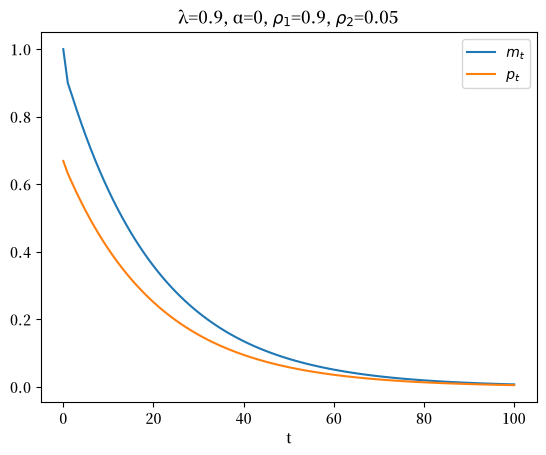

In [8]:
plt.figure()
plt.plot(range(T+1), m_seq, label=r'$m_t$')
plt.plot(range(T+1), p_seq, label=r'$p_t$')
plt.xlabel('t')
plt.title(rf'λ={λ}, α={α}, $ρ_1$={ρ1}, $ρ_2$={ρ2}')
plt.legend()
plt.show()

在上图中，为什么价格水平的对数总是小于货币供应量的对数？

因为

- 根据方程 {eq}`equation_2`，$p_t$ 是当前和未来 $m_t$ 值的几何加权平均值，并且
- 在这个例子中，未来的 $m$ 值总是小于当前的 $m$ 值

## 替代代码

我们也可以使用 quantecon 的 **LinearStateSpace** 代码来运行模拟。

以下代码块使用该代码进行计算。

In [9]:
# 构建一个 LinearStateSpace 实例

# 堆叠 G 和 F
G_ext = np.vstack([G, F])

C = np.zeros((A.shape[0], 1))

ss = qe.LinearStateSpace(A, C, G_ext, mu_0=x0)

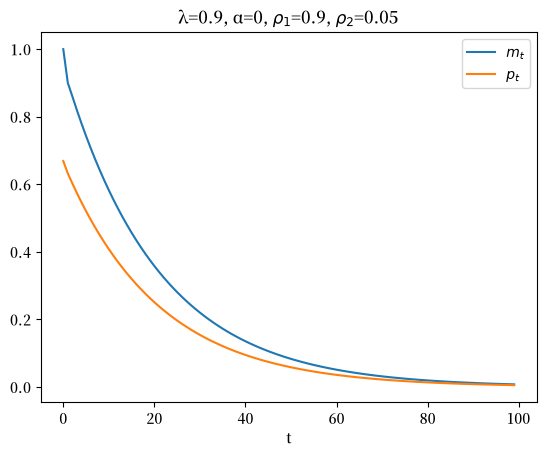

In [10]:
T = 100

# 使用LinearStateSpace进行模拟
x, y = ss.simulate(ts_length=T)

# 绘图
plt.figure()
plt.plot(range(T), y[0,:], label='$m_t$')
plt.plot(range(T), y[1,:], label='$p_t$')
plt.xlabel('t')
plt.title(f'λ={λ}, α={α}, $ρ_1$={ρ1}, $ρ_2$={ρ2}')
plt.legend()
plt.show()

### 特殊情况

为了简化我们的表述，让我们能够专注于一个重要的概念，在上述控制$m_t$的二阶差分方程{eq}`equation_6`中，我们现在设定$\alpha =0$，$\rho_1 = \rho \in (-1,1)$，以及$\rho_2 =0$，这样$m_t$的运动规律变为

```{math}
:label: equation_7

m_{t+1} =\rho m_t
```

且状态$x_t$变为

$$
x_t = m_t .
$$

因此，我们可以设定$G =1, A =\rho$，使得我们的公式{eq}`equation_5`中的$F$变为

$$
F = (1-\lambda) (1 -\lambda \rho)^{-1} .
$$

这样对数价格水平满足

$$
p_t = F m_t .
$$

在我们研究另一种推导和解释$F$公式的方法时，请记住这些公式。

## 另一个视角

在上文中，我们通过向前求解特征多项式的不稳定根，对Cagan模型中关键差分方程{eq}`equation_1`的解施加了稳定性或非爆炸性条件。

为了阐明在一个潜在不稳定的线性差分方程组解中施加稳定性的机制，并为我们的模型进行推广做准备（在这个推广中，货币供应量被允许对价格水平本身产生反馈），我们将方程{eq}`equation_1`和{eq}`equation_7`叠加形成如下系统

```{math}
:label: equation_8

\begin{bmatrix} m_{t+1} \cr p_{t+1} \end{bmatrix} = \begin{bmatrix} \rho & 0 \\ - (1-\lambda)/\lambda & \lambda^{-1}  \end{bmatrix} \begin{bmatrix} m_t \\ p_t \end{bmatrix}
```

或

```{math}
:label: equation_9

y_{t+1} = H y_t, \quad t \geq 0
```

其中

```{math}
:label: equation_10

H = \begin{bmatrix} \rho & 0 \\ - (1-\lambda)/\lambda & \lambda^{-1}  \end{bmatrix} .
```

转移矩阵$H$的特征值为$\rho \in (0,1)$和$\lambda^{-1} > 1$。

因为$H$的一个特征值大于1，如果我们从任意初始向量开始迭代方程{eq}`equation_9`

$y_0 = \begin{bmatrix} m_0 \\ p_0 \end{bmatrix}$ 其中 $m_0 >0, p_0 >0$，我们发现
通常情况下，当 $t \rightarrow + \infty$ 时，$y_t$ 的两个分量的绝对值都趋向于 $+\infty$。

为了证实这一说法，我们可以使用 $H$ 的特征向量矩阵分解，这是可行的因为 $H$ 的特征值是不同的

$$
H = Q \Lambda Q^{-1} .
$$

这里 $\Lambda$ 是 $H$ 的特征值构成的对角矩阵，$Q$ 是由与相应特征值相关的特征向量组成的矩阵。

注意到

$$
H^t = Q \Lambda^t Q^{-1}
$$

因此

$$
y_t = Q \Lambda^t Q^{-1} y_0
$$

对于几乎所有的初始向量 $y_0$，由于存在特征值 $\lambda^{-1} > 1$，$y_t$ 的两个分量的绝对值都会趋向于 $+\infty$。

为了更详细地探讨这个结果，我们可以使用以下变换

$$
y^*_t = Q^{-1} y_t
$$

这使我们能够以一种分离的方式来表示动态过程

路径发散倾向的来源：

$$
y^*_{t+1} = \Lambda^t y^*_t
$$

观察这个方程可以发现，除非

```{math}
:label: equation_11

y^*_0 = \begin{bmatrix} y^*_{1,0} \cr 0 \end{bmatrix}
```

否则当$t \rightarrow +\infty$时，$y^*_t$的路径以及$y_t = Q y^*_t$的两个分量的路径都将在绝对值上发散。（我们称这些路径*爆炸*）

方程{eq}`equation_11`还使我们得出结论，初始向量$y_0$只有一个特定取值能使$y_t$的两个分量不发散。

$y_0$的这个必要取值显然必须满足以下性质：

$$
Q y_0 =  y^*_0 = \begin{bmatrix} y^*_{1,0} \cr 0 \end{bmatrix} .
$$

但请注意，由于$y_0 = \begin{bmatrix} m_0 \cr p_0 \end{bmatrix}$且$m_0$是给定的初始条件，$p_0$必须进行所有调整以满足这个方程。

有时这种情况被描述为，虽然$m_0$

确实是一个**状态**变量，$p_0$是一个**跳跃**变量，必须在$t=0$时调整以满足方程。

因此，简而言之，使$y_t$路径不发散的向量$y_0$的唯一值必须具有第二个分量$p_0$，该分量通过将$y^*_0$的第二个分量设为零来验证等式{eq}`equation_11`。

初始向量$y_0 = \begin{bmatrix} m_0 \cr p_0 \end{bmatrix}$的分量$p_0$必须明显满足

$$
Q^{\{2\}} y_0 =0
$$

其中$Q^{\{2\}}$表示$Q^{-1}$的第二行，这个限制等价于

```{math}
:label: equation_12

Q^{21} m_0 + Q^{22} p_0 = 0
```

其中$Q^{ij}$表示$Q^{-1}$的$(i,j)$分量。

求解此方程得到$p_0$：

```{math}
:label: equation_13

p_0 = - (Q^{22})^{-1} Q^{21} m_0.
```

这是$p_0$的唯一**稳定值**，表示为$m_0$的函数。

### 完善公式

我们可以得到一个更便利的$p_0$公式，它被表示为

用 $Q$ 的分量而不是 $Q^{-1}$ 的分量来表示。

要得到这个公式，首先注意因为 $(Q^{21}\ Q^{22})$ 是 $Q$ 的逆矩阵的第二行，并且因为 $Q^{-1} Q = I$，所以有：

$$
\begin{bmatrix} Q^{21} & Q^{22} \end{bmatrix}  \begin{bmatrix} Q_{11}\cr Q_{21} \end{bmatrix} = 0
$$

这意味着：

$$
Q^{21} Q_{11} + Q^{22} Q_{21} = 0.
$$

因此，

$$
-(Q^{22})^{-1} Q^{21} = Q_{21} Q^{-1}_{11}.
$$

所以我们可以写成：

```{math}
:label: equation_14

p_0 = Q_{21} Q_{11}^{-1} m_0 .
```

可以验证这个公式在时间上会自我复制，即：

```{math}
:label: equation_15

p_t = Q_{21} Q^{-1}_{11} m_t.
```

要实现公式 {eq}`equation_15`，我们需要计算 $Q_1$，即与 $Q$ 的稳定特征值 $\rho$ 相关的特征向量。

通过手工计算可以验证，与稳定特征值 $\rho$ 相关的特征向量与下式成比例：

$$

Q_1  = \begin{bmatrix} 1-\lambda  \rho \\ 1 - \lambda   \end{bmatrix}.
$$

注意，如果我们在之前的 $p_t$ 公式中设定 $A=\rho$ 和 $G=1$，我们得到

$$
p_t = G (I - \lambda A)^{-1} m_t =  (1-\lambda) (1 - \lambda \rho)^{-1} m_t ,
$$

这个公式等价于

$$
p_t = Q_{21} Q_{11}^{-1}  m_t ,
$$

其中

$$
Q_1 = \begin{bmatrix} Q_{11} \\ Q_{21}  \end{bmatrix}.
$$

### 关于反馈的说明

我们已经将{eq}`equation_8`表达成一个表面上看起来是 $y_{t+1}$ 对 $y_t$ 进行反馈的形式，尽管我们实际想要表达的是分量 $p_t$ 向 $p_{t+1}$ **前馈**，并通过它向未来的 $m_{t+j}$，$j = 0, 1, 2, \ldots$ 前馈。

一个提示我们应该超越其表面"反馈"形式的明显迹象是 $\lambda^{-1} > 1$，因此{eq}`equation_8`中的矩阵 $H$ 是**不稳定的**

- 它有一个模小于1的特征值 $\rho$，这不会危及稳定性，但是...

- 它有第二个特征值 $\lambda^{-1}$，其模大于1，这使得 $H$ 成为一个不稳定矩阵

让我们记住这些观察结果，现在转向一个对数货币供应实际上会对价格水平的对数产生反馈的情况。

## 对数货币供应对对数价格水平的反馈

当存在从对数价格水平到对数货币供应的*反馈*时，特征值在1的两侧分布的情况（一个小于1，另一个大于1）有时会出现。

让反馈规则为

```{math}
:label: equation_16

m_{t+1} =  \rho m_t + \delta p_t
```

其中 $\rho \in (0,1)$，现在我们允许 $\delta \neq 0$。

**警告：** 如果我们希望系统对某个我们想要唯一确定的初始值 $p_0$ 保持稳定，$\delta$ 不能太大。

前瞻性方程 {eq}`equation_1` 继续描述货币需求和供给的均衡。

我们假设方程 {eq}`equation_1` 和 {eq}`equation_16` 控制着
$y_t \equiv \begin{bmatrix} m_t \cr p_t \end{bmatrix}$，其中
$t \geq 0$。

运动规律中的转移矩阵 $H$

$$
y_{t+1} = H y_t
$$

现在变为

$$
H = \begin{bmatrix} \rho & \delta \\ - (1-\lambda)/\lambda & \lambda^{-1}  \end{bmatrix} .
$$

我们将 $m_0$ 作为给定的初始条件，并像之前一样寻找一个初始值 $p_0$ 使系统稳定，即
$y_t$ 在 $t \rightarrow + \infty$ 时收敛。

我们采用的方法与上面相同，基于特征值分解，我们希望一个特征值大于1，另一个特征值的绝对值小于1。

当我们现在假设 $\delta \neq 0$ 时，$H$ 的特征值将不再是
$\rho \in (0,1)$ 和 $\lambda^{-1} > 1$

我们只需计算这些特征值，并应用与上面相同的算法。

只要特征值仍然像之前那样在1的两侧分布，该算法就依然有效。

我们再次假设 $m_0$ 是一个初始条件，但是 $p_0$ 不是给定的，而是需要求解的。

让我们编写并执行一些Python代码，来探索结果如何依赖于 $\delta$。

In [11]:
def construct_H(ρ, λ, δ):
    "根据参数构建矩阵H。"

    H = np.empty((2, 2))
    H[0, :] = ρ,δ
    H[1, :] = - (1 - λ) / λ, 1 / λ

    return H

def H_eigvals(ρ=.9, λ=.5, δ=0):
    "根据参数计算矩阵H的特征值。"

    # 构建H矩阵
    H = construct_H(ρ, λ, δ)

    # 计算特征值
    eigvals = np.linalg.eigvals(H)

    return eigvals

In [12]:
H_eigvals()

array([2. , 0.9])

注意即使负的 $\delta$ 有很大的绝对值，也不会危及矩阵 $H$ 的稳定性。

In [13]:
# 小的负 δ
H_eigvals(δ=-0.05)

array([0.8562829, 2.0437171])

In [14]:
# 较大的负δ值
H_eigvals(δ=-1.5)

array([0.10742784, 2.79257216])

一个足够小的正数 $\delta$ 也不会造成问题。

In [15]:
# 足够小的正数 δ
H_eigvals(δ=0.05)

array([0.94750622, 1.95249378])

但是足够大的正值 $\delta$ 会使 $H$ 的两个特征值的模都严格大于1。

例如，

In [16]:
H_eigvals(δ=0.2)

array([1.12984379, 1.77015621])

我们要研究的是这样的系统：一个特征值的模大于1，而另一个特征值的模小于1，因此我们要避免$\delta$的值过大。

也就是说，我们要避免从$p_t$到$m_{t+1}$的正反馈过强。

In [17]:
def magic_p0(m0, ρ=.9, λ=.5, δ=0):
    """
    使用魔法公式(8)计算使系统稳定的p0水平。
    """

    H = construct_H(ρ, λ, δ)
    eigvals, Q = np.linalg.eig(H)

    # 找到较小特征值的索引
    ind = 0 if eigvals[0] < eigvals[1] else 1

    # 验证特征值是否小于1
    if eigvals[ind] > 1:

        print("两个特征值的模都大于1")

        return None

    p0 = Q[1, ind] / Q[0, ind] * m0

    return p0

让我们绘制在不同的$\delta$设置下，$p_0$如何随着$m_0$的变化而变化。

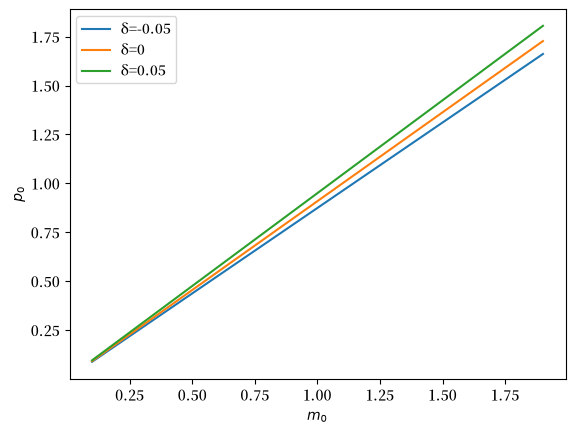

In [18]:
m_range = np.arange(0.1, 2., 0.1)

for δ in [-0.05, 0, 0.05]:
    plt.plot(m_range, [magic_p0(m0, δ=δ) for m0 in m_range], label=f"δ={δ}")
plt.legend()

plt.xlabel(r"$m_0$")
plt.ylabel(r"$p_0$")
plt.show()

从另一个角度来看，我们可以固定初始值$m_0$，观察当$\delta$变化时$p_0$如何变化。

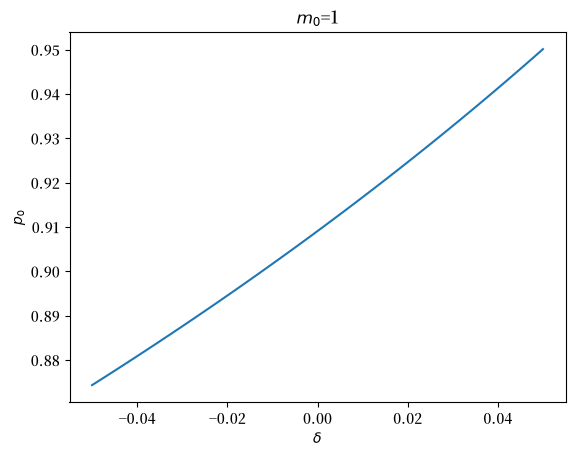

In [19]:
m0 = 1

δ_range = np.linspace(-0.05, 0.05, 100)
plt.plot(δ_range, [magic_p0(m0, δ=δ) for δ in δ_range])
plt.xlabel(r'$\delta$')
plt.ylabel(r'$p_0$')
plt.title(rf'$m_0$={m0}')
plt.show()

注意当 $\delta$ 足够大时，两个特征值的模都大于1，这导致不存在能使系统稳定的 $p_0$ 值。

In [20]:
magic_p0(1, δ=0.2)

两个特征值的模都大于1


## 大 $P$，小 $p$ 解释

从价格水平或通货膨胀对货币或货币创造率的反馈角度来看待差分方程的解，用{doc}`理性预期模型 <rational_expectations>`中讨论的大 $K$，小 $k$ 的思路来理解会很有帮助。

这将帮助我们理清，当决策者使用差分方程{eq}`equation_2`来根据他们对未来$m_t$值的预测确定$p_t$时，哪些是被视为既定的。

让我们将使用$H$的特征向量分解计算得到的稳定解写作$P_t = F^* m_t$，其中

$$
F^* = Q_{21} Q_{11}^{-1} .
$$

然后从$P_{t+1} = F^* m_{t+1}$和$m_{t+1} = \rho m_t + \delta P_t$，我们可以推导出递归式$P_{t+1} = F^* \rho m_t + F^* \delta P_t$并创建堆叠系统

$$
\begin{bmatrix} m_{t+1} \cr P_{t+1} \end{bmatrix}  =    \begin{bmatrix} \rho & \delta \cr

F^* \rho & F^* \delta   \end{bmatrix} \begin{bmatrix} m_t \cr P_t \end{bmatrix}
$$

或

$$
x_{t+1} = A x_t
$$

其中 $x_t = \begin{bmatrix} m_t \cr P_t \end{bmatrix}$。

应用公式 {eq}`equation_5` 对 $F$ 推导得出

$$
p_t = F \begin{bmatrix} m_t \cr P_t \end{bmatrix} = F \begin{bmatrix} m_t \cr F^* m_t \end{bmatrix}
$$

这意味着

$$
p_t = \begin{bmatrix} F_1 & F_2 \end{bmatrix}    \begin{bmatrix} m_t \cr F^* m_t \end{bmatrix} = F_1 m_t + F_2 F^* m_t
$$

因此我们可以预期

$$
F^* = F_1 + F_2 F^*
$$

我们将在下一个Python代码块中验证这个等式，该代码块实现以下计算。

1. 对于 $\delta\neq 0$ 的系统（即存在反馈的系统），
   我们计算 $p_t$ 的稳定解，形式为
   $p_t = F^* m_t$，其中 $F^* = Q_{21}Q_{11}^{-1}$，如上所述。
1. 回顾上面的系统 {eq}`equation_3`、{eq}`equation_4` 和 {eq}`equation_5`，我们定义

$x_t = \begin{bmatrix} m_t \cr P_t \end{bmatrix}$ 请注意
   这里是大写的 $P_t$ 而不是小写的 $p_t$。然后我们构建 $A$ 和 $G$ 为
   $A = \begin{bmatrix}\rho & \delta \cr F^* \rho & F^*\delta \end{bmatrix}$
   和 $G = \begin{bmatrix} 1 & 0 \end{bmatrix}$ 并且我们从上面的
   方程 {eq}`equation_5` 计算
   $\begin{bmatrix}  F_1 &  F_2 \end{bmatrix} \equiv F$。
1. 我们计算 $F_1 +  F_2 F^*$ 并将其
   与 $F^*$ 进行比较，检验是否符合预期的等式。

In [21]:
# 设置参数
ρ = .9
λ = .5
δ = .05

In [22]:
# 求解 F_star
H = construct_H(ρ, λ, δ)
eigvals, Q = np.linalg.eig(H)

ind = 0 if eigvals[0] < eigvals[1] else 1
F_star = Q[1, ind] / Q[0, ind]
F_star

In [23]:
# 求解 F_check
A = np.empty((2, 2))
A[0, :] = ρ, δ
A[1, :] = F_star * A[0, :]

G = np.array([1, 0])

F_check= (1 - λ) * G @ np.linalg.inv(np.eye(2) - λ * A)
F_check

array([0.92755597, 0.02375311])

比较 $F^*$ 与 $F_1 + F_2 F^*$

In [24]:
F_check[0] + F_check[1] * F_star, F_star

## 玩转 SymPy

本节是给坚持读到这里的读者的一份礼物。

我们将使用 SymPy 来处理我们的模型。

具体来说，我们使用 SymPy 来计算 $H$ 的特征向量分解中的一些关键对象。

我们首先生成一个具有非零 $\delta$ 的 $H$。

In [25]:
λ, δ, ρ = symbols('λ, δ, ρ')

In [26]:
H1 = Matrix([[ρ,δ], [- (1 - λ) / λ, λ ** -1]])

In [27]:
H1

⎡  ρ    δ⎤
⎢        ⎥
⎢λ - 1  1⎥
⎢─────  ─⎥
⎣  λ    λ⎦

In [28]:
H1.eigenvals()

In [29]:
H1.eigenvects()

⎡⎛                                                      ⎡⎡  ⎛             ____ ↪
⎢⎜             ____________________________________     ⎢⎢  ⎜            ╱     ↪
⎢⎜            ╱      2            2  2                  ⎢⎢  ⎜λ⋅ρ + 1   ╲╱  4⋅δ ↪
⎢⎜λ⋅ρ + 1   ╲╱  4⋅δ⋅λ  - 4⋅δ⋅λ + λ ⋅ρ  - 2⋅λ⋅ρ + 1      ⎢⎢λ⋅⎜─────── - ─────── ↪
⎢⎜─────── - ───────────────────────────────────────, 1, ⎢⎢  ⎝  2⋅λ             ↪
⎢⎜  2⋅λ                       2⋅λ                       ⎢⎢──────────────────── ↪
⎢⎜                                                      ⎢⎢                     ↪
⎢⎜                                                      ⎢⎢                     ↪
⎣⎝                                                      ⎣⎣                     ↪

↪ ________________________________⎞        ⎤⎤⎞  ⎛                              ↪
↪   2            2  2             ⎟        ⎥⎥⎟  ⎜             ________________ ↪
↪ ⋅λ  - 4⋅δ⋅λ + λ ⋅ρ  - 2⋅λ⋅ρ + 1 ⎟        ⎥⎥⎟  ⎜            ╱      2          ↪
↪ ─────────────────────────

现在让我们计算当 $\delta$ 为零时的 $H$。

In [30]:
H2 = Matrix([[ρ,0], [- (1 - λ) / λ, λ ** -1]])

In [31]:
H2

⎡  ρ    0⎤
⎢        ⎥
⎢λ - 1  1⎥
⎢─────  ─⎥
⎣  λ    λ⎦

In [32]:
H2.eigenvals()

In [33]:
H2.eigenvects()

⎡               ⎛      ⎡⎡λ⋅ρ - 1⎤⎤⎞⎤
⎢⎛1     ⎡⎡0⎤⎤⎞  ⎜      ⎢⎢───────⎥⎥⎟⎥
⎢⎜─, 1, ⎢⎢ ⎥⎥⎟, ⎜ρ, 1, ⎢⎢ λ - 1 ⎥⎥⎟⎥
⎢⎝λ     ⎣⎣1⎦⎦⎠  ⎜      ⎢⎢       ⎥⎥⎟⎥
⎣               ⎝      ⎣⎣   1   ⎦⎦⎠⎦

下面我们让SymPy为我们分析性地完成以下有趣的计算：

1. 我们计算矩阵$Q$，其第一列是与$\rho$相关的特征向量，第二列是与$\lambda^{-1}$相关的特征向量。
1. 我们使用SymPy计算$Q$的逆矩阵$Q^{-1}$（都用符号表示）。
1. 我们使用SymPy计算$Q_{21} Q_{11}^{-1}$（用符号表示）。
1. 其中$Q^{ij}$表示$Q^{-1}$的$(i,j)$分量，我们使用SymPy计算$- (Q^{22})^{-1} Q^{21}$（同样用符号表示）

In [34]:
# 构造Q
vec = []
for i, (eigval, _, eigvec) in enumerate(H2.eigenvects()):

    vec.append(eigvec[0])

    if eigval == ρ:
        ind = i

Q = vec[ind].col_insert(1, vec[1-ind])

In [35]:
Q

⎡λ⋅ρ - 1   ⎤
⎢───────  0⎥
⎢ λ - 1    ⎥
⎢          ⎥
⎣   1     1⎦

$Q^{-1}$

In [36]:
Q_inv = Q ** (-1)
Q_inv

⎡ λ - 1    ⎤
⎢───────  0⎥
⎢λ⋅ρ - 1   ⎥
⎢          ⎥
⎢ 1 - λ    ⎥
⎢───────  1⎥
⎣λ⋅ρ - 1   ⎦

$Q_{21}Q_{11}^{-1}$

In [37]:
Q[1, 0] / Q[0, 0]

$−(Q^{22})^{−1}Q^{21}$

In [38]:
- Q_inv[1, 0] / Q_inv[1, 1]